# MatRisk AI — Commodity Risk Intelligence Platform

## Objective
This project aims to build an AI-powered financial risk intelligence platform using commodity futures data, risk analytics, simulation systems, and machine learning.

## Goals
- Analyze commodity market behavior
- Predict commodity risk and volatility
- Simulate financial shock scenarios
- Generate portfolio risk insights
- Build an interactive AI-powered dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/raw/commodity_futures.csv")

df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96


In [3]:
df.shape

(6092, 24)

In [4]:
df.columns

Index(['Date', 'NATURAL GAS', 'GOLD', 'WTI CRUDE', 'BRENT CRUDE', 'SOYBEANS',
       'CORN', 'COPPER', 'SILVER', 'LOW SULPHUR GAS OIL', 'LIVE CATTLE',
       'SOYBEAN OIL', 'ALUMINIUM', 'SOYBEAN MEAL', 'ZINC', 'ULS DIESEL',
       'NICKEL', 'WHEAT', 'SUGAR', 'GASOLINE', 'COFFEE', 'LEAN HOGS',
       'HRW WHEAT', 'COTTON'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6092 entries, 0 to 6091
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6092 non-null   object 
 1   NATURAL GAS          6083 non-null   float64
 2   GOLD                 6082 non-null   float64
 3   WTI CRUDE            6083 non-null   float64
 4   BRENT CRUDE          6090 non-null   float64
 5   SOYBEANS             6083 non-null   float64
 6   CORN                 6084 non-null   float64
 7   COPPER               6083 non-null   float64
 8   SILVER               6079 non-null   float64
 9   LOW SULPHUR GAS OIL  6090 non-null   float64
 10  LIVE CATTLE          6084 non-null   float64
 11  SOYBEAN OIL          6079 non-null   float64
 12  ALUMINIUM            6045 non-null   float64
 13  SOYBEAN MEAL         6082 non-null   float64
 14  ZINC                 6046 non-null   float64
 15  ULS DIESEL           6083 non-null   f

In [6]:
df.describe()

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
count,6083.000000,6082.000000,6083.000000,6090.000000,6083.000000,6084.000000,6083.00000,6079.000000,6090.000000,6084.000000,...,6046.000000,6083.000000,6046.00000,6078.000000,6083.000000,4601.000000,6080.000000,6084.000000,6078.000000,6079.000000
mean,4.512820,1069.113877,62.877018,66.197107,981.329196,403.801940,2.62252,16.117507,587.144089,106.566872,...,2083.550792,192.132829,16132.29213,527.912636,14.474947,212.931287,128.633651,72.269975,553.925263,71.294975
std,2.232842,533.170926,25.875847,29.167645,343.612998,165.325847,1.12989,8.448539,262.621329,26.341295,...,848.585858,84.462845,7749.70740,190.460886,5.876186,63.462659,50.737193,16.819020,204.975088,25.202066
min,1.482000,255.100000,-37.630000,17.680000,418.000000,174.750000,0.60600,4.028000,148.500000,59.400000,...,724.000000,49.990000,4350.00000,233.500000,4.650000,41.180000,41.500000,30.050000,270.750000,28.520000
25%,2.835000,492.450000,42.180000,43.532500,662.875000,251.437500,1.65825,8.180000,384.250000,85.425000,...,1294.625000,126.400000,10620.62500,377.312500,9.935000,161.600000,99.250000,59.950000,399.062500,55.535000
50%,3.895000,1202.700000,60.550000,63.630000,957.000000,368.750000,2.84550,16.272000,570.000000,104.537500,...,2076.875000,187.890000,14671.00000,504.500000,13.630000,206.380000,121.100000,69.150000,495.500000,66.770000
75%,5.671500,1473.400000,82.485000,85.692500,1285.125000,514.750000,3.44650,20.664000,779.750000,124.031250,...,2626.687500,255.820000,19336.12500,653.750000,18.240000,264.600000,150.825000,82.300000,702.437500,81.795000
max,15.378000,2055.700000,145.290000,146.080000,1771.000000,831.250000,4.92900,48.584000,1522.500000,181.325000,...,4594.000000,513.540000,53750.00000,1425.250000,35.310000,427.620000,304.900000,133.875000,1367.750000,215.150000


In [7]:
df.isnull().sum()

Date                      0
NATURAL GAS               9
GOLD                     10
WTI CRUDE                 9
BRENT CRUDE               2
SOYBEANS                  9
CORN                      8
COPPER                    9
SILVER                   13
LOW SULPHUR GAS OIL       2
LIVE CATTLE               8
SOYBEAN OIL              13
ALUMINIUM                47
SOYBEAN MEAL             10
ZINC                     46
ULS DIESEL                9
NICKEL                   46
WHEAT                    14
SUGAR                     9
GASOLINE               1491
COFFEE                   12
LEAN HOGS                 8
HRW WHEAT                14
COTTON                   13
dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

df.head()

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,69.700,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,69.075,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,68.975,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,70.075,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,70.875,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96


In [9]:
df.drop(columns=['GASOLINE'], inplace=True)

In [10]:
df.fillna(method='ffill', inplace=True)

/var/folders/g3/9ydsd92n1nj42lt_rb5xyzxc0000gn/T/ipykernel_89641/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

NATURAL GAS            0
GOLD                   0
WTI CRUDE              0
BRENT CRUDE            0
SOYBEANS               0
CORN                   0
COPPER                 0
SILVER                 0
LOW SULPHUR GAS OIL    0
LIVE CATTLE            0
SOYBEAN OIL            0
ALUMINIUM              0
SOYBEAN MEAL           0
ZINC                   0
ULS DIESEL             0
NICKEL                 0
WHEAT                  0
SUGAR                  0
COFFEE                 0
LEAN HOGS              0
HRW WHEAT              0
COTTON                 0
dtype: int64

## Missing Value Handling

The dataset contained minimal missing values across most commodity futures series. 

However, the `GASOLINE` feature had excessive missing data and was removed to maintain data quality.

Remaining missing observations were handled using forward-fill imputation, a common technique in financial time-series analysis that preserves temporal continuity.

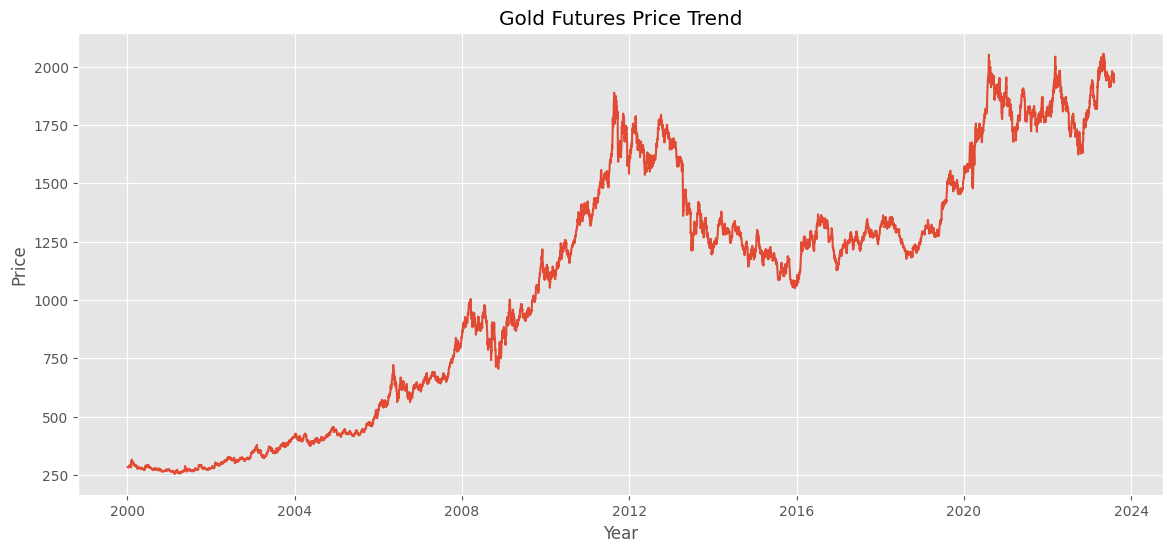

In [13]:
plt.figure(figsize=(14,6))

plt.plot(df['GOLD'])

plt.title("Gold Futures Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

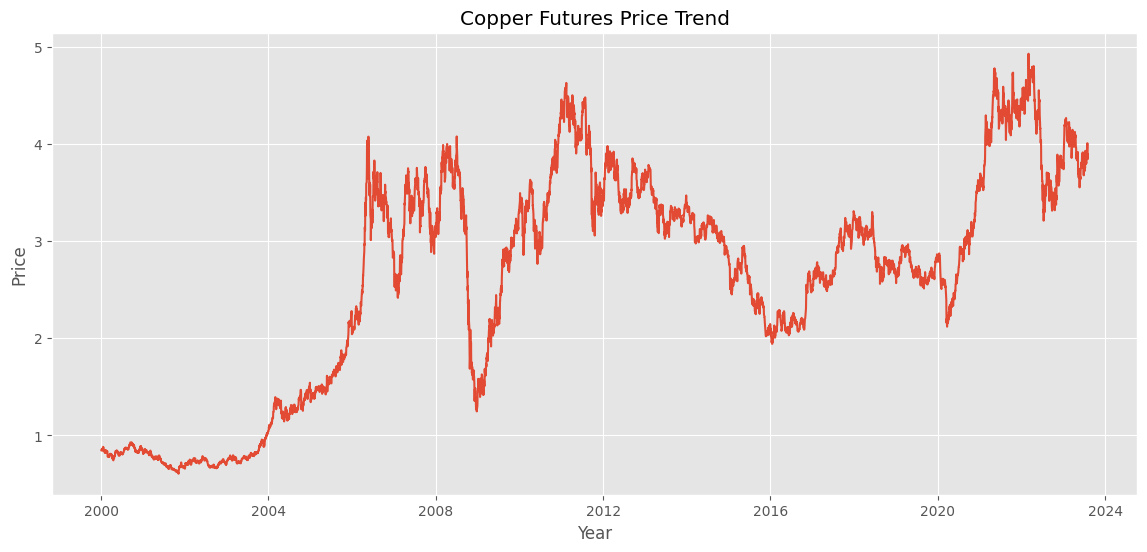

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df['COPPER'])

plt.title("Copper Futures Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

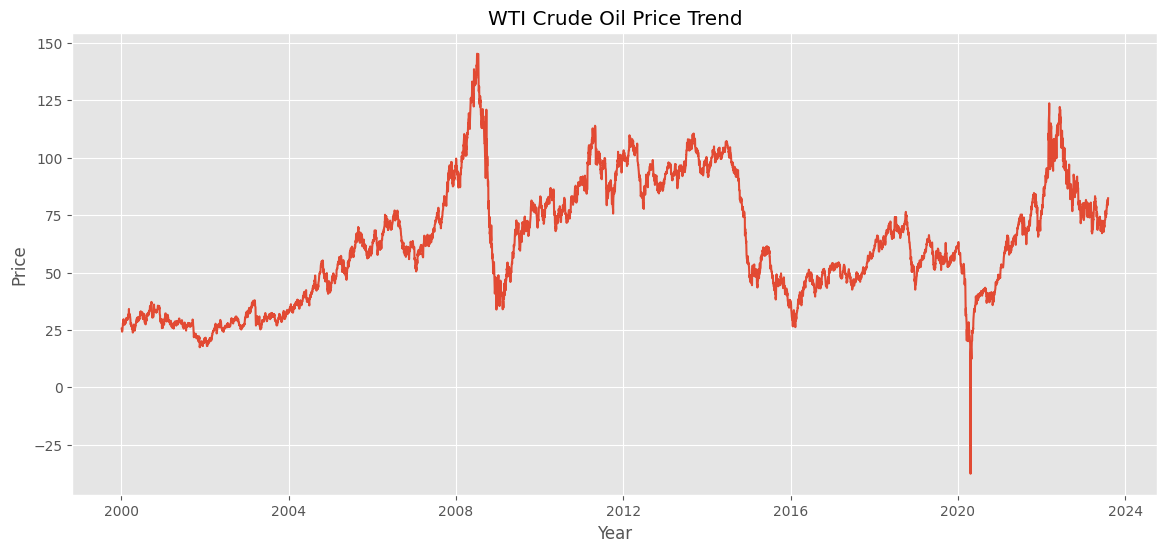

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df['WTI CRUDE'])

plt.title("WTI Crude Oil Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

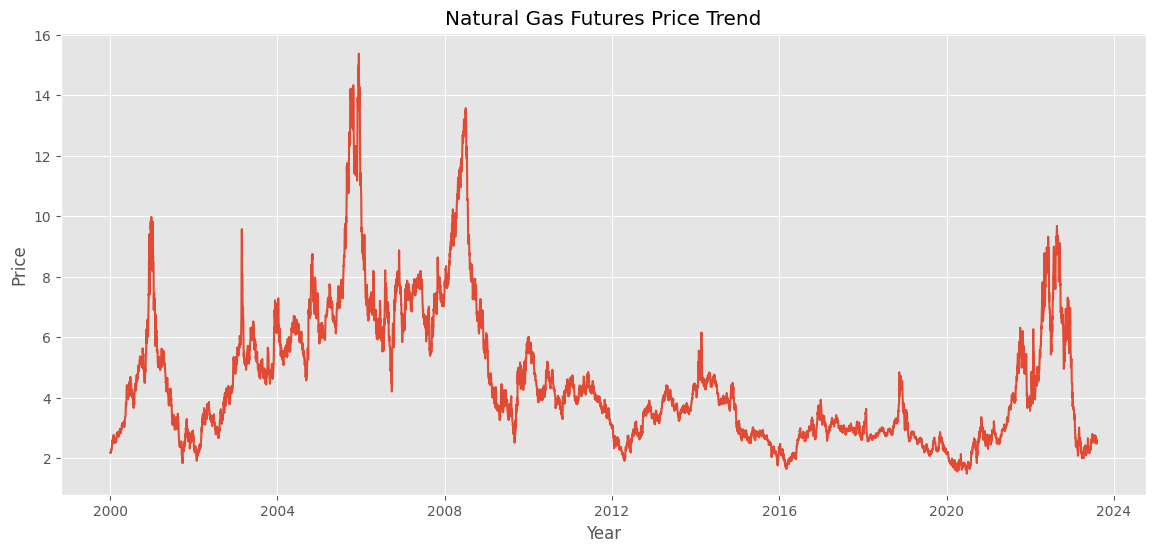

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df['NATURAL GAS'])

plt.title("Natural Gas Futures Price Trend")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

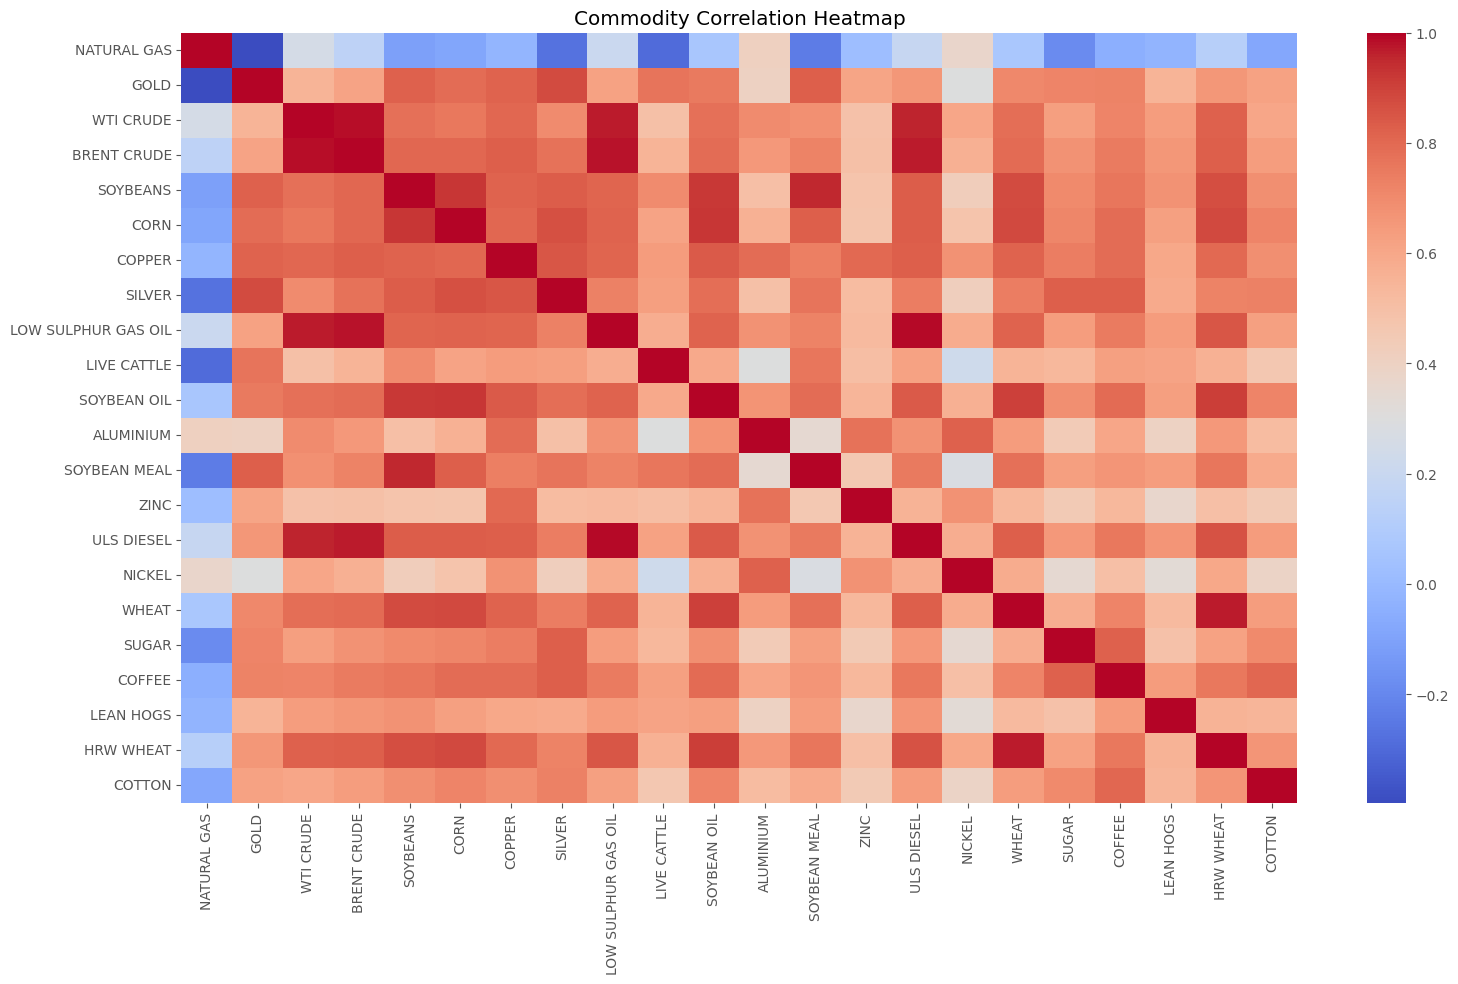

In [17]:
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(18,10))

sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title("Commodity Correlation Heatmap")

plt.show()

## Key Observations

- Gold prices exhibit relatively stable long-term growth patterns.
- Oil and natural gas display high volatility due to geopolitical and macroeconomic factors.
- Industrial commodities like copper and aluminium show cyclical behavior linked to global economic activity.
- Several commodities demonstrate strong positive correlations, useful for portfolio risk analysis and diversification modelling.

In [18]:
df.to_csv("../data/processed/cleaned_commodity_futures.csv")